In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from sklearn.metrics import mean_squared_error

import warnings 
warnings.filterwarnings('ignore') 

sys.path.append("../../")
import stan


## Loading ST dataset
We use a Visium spatial transcriptomics dataset of the human glioblastoma, which is publicly available from the 10x genomics website. For first time use, the dataset will be downloaded to the directory data/Parent_Visium_Human_Glioblastoma by default.

In [2]:
adata = sc.datasets.visium_sge(sample_id="Parent_Visium_Human_Glioblastoma")
adata.var_names_make_unique()
adata

100%|██████████| 8.71M/8.71M [00:02<00:00, 3.95MB/s]


100%|██████████| 19.5M/19.5M [00:02<00:00, 7.46MB/s]


AnnData object with n_obs × n_vars = 3468 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

We perform some basic filtering of genes and spots.

In [3]:
sc.pp.filter_genes(adata, min_cells=5)
sc.pp.filter_cells(adata, min_counts=500)
adata

AnnData object with n_obs × n_vars = 3462 × 20950
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

Write the processed data to file.

In [4]:
!mkdir results_glioblastoma/
adata.write("results_glioblastoma/glioblastoma.h5ad")

## Loading the gene-TF prior matrix

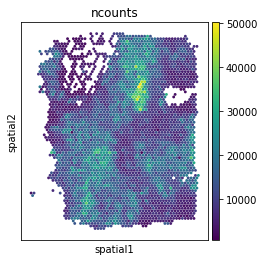

<Axes: >

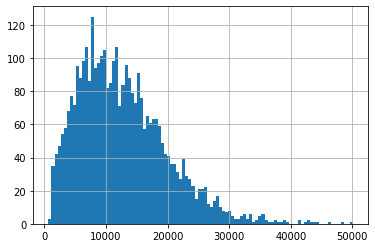

In [5]:
adata.layers['raw'] = adata.X
adata.obs['ncounts'] = adata.to_df('raw').T.sum()
sc.pl.spatial(adata, color='ncounts', size=1.5, alpha_img=0)
adata.obs['ncounts'].hist(bins=100)

In [6]:
adata = stan.add_gene_tf_matrix(adata,
                                min_cells_proportion = 0.2,
                                min_tfs_per_gene= 5,
                                min_genes_per_tf= 10,
                                gene_tf_source="hTFtarget",
                                tf_list="humantfs",
                                source_dir="../data/gene_tf/")

We check the sizes of the matrices after filtering.

In [7]:
D = adata.varm['gene_tf']
print('gene-TF matrix: {} x {}'.format(D.shape[0], D.shape[1]))
print('min tfs associated with each gene: {}'.format(D.T.abs().sum().min()))
print('min genes associated with each tf: {}'.format(D.abs().sum().min()))

gene-TF matrix: 7254 x 222
min tfs associated with each gene: 5
min genes associated with each tf: 10


In [8]:
Y = adata.to_df()
print('gene-cell matrix: {} x {}'.format(Y.shape[1], Y.shape[0]))
print('min cells associated with each gene: {}'.format((Y>0).sum().min()))
print('min genes associated with each cell: {}'.format((Y>0).T.sum().min()))

gene-cell matrix: 7254 x 3462
min cells associated with each gene: 693
min genes associated with each cell: 412


## Computing the spatially dependent kernel

In [9]:
stan.pixel_intensity(adata, windowsize=25)
stan.make_kernel(adata, n=250, im_feats_weight=0.05, bandwidth=0.2)

Time elapsed: 0.25 seconds
Time elapsed: 5.16 seconds


In [10]:
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())

## TF activity inference

In [11]:
stan.assign_folds(adata, n_folds=10, random_seed=0)

### STAN

In [12]:
stan_model = stan.Stan(adata, layer='scaled')
stan_model.fit(n_steps=5, stages=1,
              grid_search_params={'lam1':[1e-4, 1e4], 'lam2':[1e-4, 1e4]})

Time elapsed: 100.18 seconds


Evaluate the cross validation performance using Pearsonr correlation coefficient.

In [13]:
cor, gene_cor = stan_model.evaluate(fold=-1)
adata.obs['pred_cor_stan'] = cor
adata.var['pred_cor_stan'] = gene_cor

print(stan_model.params)
print("Spot-wise correlation:" + str(round(np.nanmedian(cor), 4)))
print("Gene-wise correlation: " + str(round(np.nanmedian(gene_cor), 4)))

{'lam1': 10000.0, 'lam2': 100.0}
Spot-wise correlation:0.2422
Gene-wise correlation: 0.1635


Evaluate the validation performance using mean squared error.

In [14]:
Y = adata.varm['gene_tf'].dot(stan_model.W_concat)
mean_squared_error(Y, adata.to_df('scaled').T)

0.8486051282889377

Store the inferred TF activity matrix in adata.obsm['tfa_stan'].

In [15]:
adata.obsm['tfa_stan'] = pd.DataFrame(
    stan_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

### Ridge regression (baseline)¶

In [16]:
ridge_model = stan.Ridge(adata, layer='scaled')
ridge_model.fit(n_steps=5, stages=1,
                grid_search_params={'lam':[1e-4, 1e4]})

Time elapsed: 22.26 seconds


Evaluate the cross validation performance using Pearsonr correlation coefficient.

In [17]:
cor, gene_cor = ridge_model.evaluate(fold=-1)
adata.obs['pred_cor_ridge'] = cor
adata.var['pred_cor_ridge'] = gene_cor

print(ridge_model.params)
print("Sample Cor:" + str(round(np.nanmedian(cor), 4)))
print(" Gene Cor: " + str(round(np.nanmedian(gene_cor), 4)))

{'lam': 0.0001}
Sample Cor:0.2305
 Gene Cor: 0.1316


Evaluate the validation performance using mean squared error.

In [18]:
Y = adata.varm['gene_tf'].dot(ridge_model.W_concat)
mean_squared_error(Y, adata.to_df('scaled').T)

0.838165076834608

Store the inferred TF activity matrix in `adata.obsm['tfa_ridge']`.

In [19]:
adata.obsm['tfa_ridge'] = pd.DataFrame(
    ridge_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

## Writing the results to files¶

In [20]:
adata.write("results_glioblastoma/glioblastoma_stan.h5ad")